# Class 8: Vector Representations and Embeddings

### Agenda
1. Motivation
2. From words to vectors
3. Main idea behind embeddings (Distributional Hypothesis)
4. Static embeddings: Word2Vec and GloVe
5. Using pretrained embeddings
6. Vector arithmetic and analogies
7. Limitations of static embeddings
8. Contextual embeddings & LLMs
9. Medical applications
10. Summary

## 0. Import Packages

Run the next cell to import the libraries used in class.

If one library is missing, uncomment the installation lines.

In [1]:
# If needed, uncomment:
# !pip install -q gensim transformers sentence-transformers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import gensim.downloader as api

from transformers import AutoTokenizer, AutoModel
import torch

from sentence_transformers import SentenceTransformer

sns.set_theme(style='whitegrid')
np.set_printoptions(precision=3, suppress=True)

import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')

## 1. Motivation

**Question:** How can a computer understand that *physician* and *doctor* are similar, while *doctor* and *banana* are not?

Embeddings are numerical representations of language where semantic meaning is captured geometrically: similar meanings are close in vector space.

A tiny visual intuition: nearby points represent similar meanings.

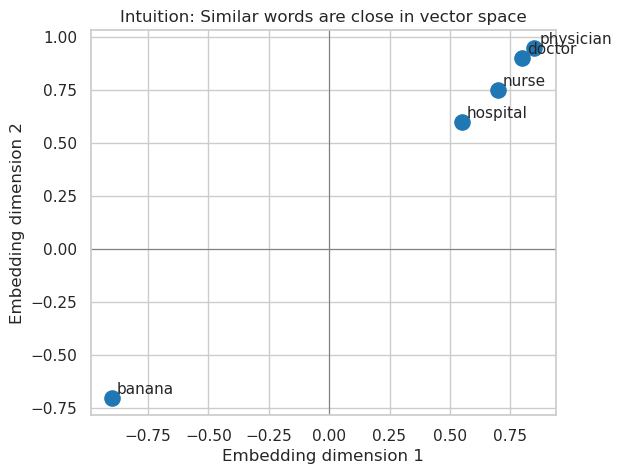

In [2]:
words = ['doctor', 'physician', 'banana', 'nurse', 'hospital']
coords = np.array([
    [0.8, 0.9],   # doctor
    [0.85, 0.95], # physician
    [-0.9, -0.7], # banana
    [0.7, 0.75],  # nurse
    [0.55, 0.6]   # hospital
])

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], s=120, color='#1f77b4')
for w, (x, y) in zip(words, coords):
    plt.text(x + 0.02, y + 0.02, w, fontsize=11)
plt.title('Intuition: Similar words are close in vector space')
plt.xlabel('Embedding dimension 1')
plt.ylabel('Embedding dimension 2')
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(0, color='gray', lw=0.8)
plt.show()

### Embeddings Visualization
Go to https://projector.tensorflow.org/ and visualize Word2Vec embeddings. 

## 2. From Words to Vectors

### Vocabulary
A **vocabulary** is the set of words we know.

### One-hot encoding
Each word is represented by a long vector with one `1` and all other entries `0`.

### Why one-hot is limited
- It does not capture similarity.
- `doctor` and `physician` equally distant as `doctor` and `banana`.
- Vectors are very high-dimensional and sparse.

### Dense embeddings
Dense vectors are shorter and encode useful patterns (semantic relationships).

One-hot example (conceptual) vs dense embeddings.

In [3]:
vocab = ['doctor', 'physician', 'banana', 'patient']
one_hot = pd.get_dummies(pd.Series(vocab), dtype=int)
one_hot.index = vocab

print('One-hot representation:')
display(one_hot)

print('\nDense embeddings:')
dense = pd.DataFrame(
    [[0.71, 0.62, 0.11],
     [0.73, 0.60, 0.10],
     [-0.55, 0.10, 0.91],
     [0.68, 0.58, 0.20]],
    index=vocab,
    columns=['dim1', 'dim2', 'dim3']
)
display(dense)

One-hot representation:


,banana,doctor,patient,physician
doctor,0,1,0,0
physician,0,0,0,1
banana,1,0,0,0
patient,0,0,1,0



Dense embeddings:


,dim1,dim2,dim3
doctor,0.71,0.62,0.11
physician,0.73,0.60,0.10
banana,-0.55,0.10,0.91
patient,0.68,0.58,0.20


> **Exercise:** Why is one-hot insufficient for medical synonyms like *hypertension* and *high blood pressure*?

## 3. The Main Idea Behind Embeddings

### Distributional Hypothesis
**“You shall know a word by the company it keeps” J.R. Firth**
- Words that appear in similar contexts tend to have similar meanings.

Example intuition:
- "The **doctor** examined the patient in the hospital."
- "The **physician** examined the patient in the clinic."

Because *doctor* and *physician* appear in similar contexts, models learn nearby vectors for them.

## 4. Static Word Embeddings

Early methods such as **Word2Vec** and **GloVe** learned one fixed vector per word.

- Every word gets one embedding.
- Similar words are close in vector space.

### Word2Vec in one minute
- **CBOW:** predict a word from surrounding context words.
- **Skip-Gram:** predict surrounding context words from one center word.
![vectors](https://lena-voita.github.io/resources/lectures/word_emb/w2v/cbow_skip-min.png)

*the image is taken for [Lena Voita's blog](https://lena-voita.github.io/nlp_course/word_embeddings.html#main_content)     
*if interested, please, check it out, it is very informative and illustrative

### GloVe in one minute
- Learns vectors from global word co-occurrence statistics.

## 5. Using Pretrained Embeddings (GloVe)

Instead of training embeddings from scratch, we can load pretrained vectors.

Load GloVe embeddings (this may take a moment the first time).

In [4]:
glove = api.load('glove-wiki-gigaword-100')
print(f'Vocabulary size: {len(glove):,}')
print(f'Vector dimension: {glove.vector_size}')

Vocabulary size: 400,000
Vector dimension: 100


Retrieve one word embedding.

In [5]:
word = 'doctor'
vec = glove[word]
print(f'First 10 values of embedding for "{word}":')
print(vec[:10])

First 10 values of embedding for "doctor":
[ 0.043 -0.475  0.158  0.204 -0.154  0.723  0.261  0.209 -0.315 -0.07 ]


Find similar words using cosine similarity (built-in).

In [ ]:
targets = ['doctor', 'hospital', 'patient', 'diabetes']
for target in targets:
    print(f'\n   Top similar words to "{target}":')
    for word, score in glove.most_similar(target, topn=5):
        print(word, ' -> cosine = ', {score})

> **Exercise:** Choose one medical term (e.g., *cancer*, *insulin*, *infection*) and inspect its nearest neighbors. Are they clinically meaningful?

## 6. Vector Arithmetic and Analogies

Some semantic relationships appear as directions in embedding space.

Classic example:

`king - man + woman ≈ queen`

Intuition: if a vector difference represents a relation, we can apply that relation elsewhere.

![analogies](https://jalammar.github.io/images/word2vec/king-analogy-viz.png)

Analogy examples with pretrained embeddings.

In [ ]:
analogies = [
    (['king', 'woman'], ['man']),
    (['walking', 'swim'], ['walk'])
]

for pos, neg in analogies:
    result = glove.most_similar(positive=pos, negative=neg, topn=3)
    expr = ' + '.join(pos) + ' - ' + ' - '.join(neg)
    print(f'\n{expr}')
    for w, s in result:
        print(f'  {w:12s} cosine={s:.3f}')

These are not perfect rules, but they show embeddings can encode relationships beyond simple similarity.

## 7. Limitations of Static Embeddings

In static embeddings, each word has only **one** vector, regardless of context.

Examples:
- **bank**: financial institution vs river bank
- **patient**: person receiving care vs adjective meaning tolerant

This is a major limitation in medical and clinical text where context is crucial.

Check that static embeddings return exactly one vector per word.

In [8]:
for w in ['bank', 'patient']:
    print(w, glove[w][:6])

print('\nSame vector is used no matter the sentence context.')

bank [ 0.419 -0.922  0.049  0.118  0.221 -0.325]
patient [-0.193  0.168  0.124  0.642 -0.78   0.96 ]

Same vector is used no matter the sentence context.


## 8. Contextual Embeddings & LLMs

Modern models (e.g., BERT) produce embeddings that depend on the sentence.

Compare:
- "The patient went to the bank after discharge."
- "The fisherman sat by the bank."

Now the word **bank** can have different vectors.


Embeddings in LLMs follow this high-level pipeline:

**Text -> Tokenization -> Embeddings -> Transformer -> Output**

Embeddings are the first step in systems like ChatGPT and many medical language models.

## 9. Medical Applications of Embeddings

Embeddings enable practical healthcare AI tasks such as:
- Finding similar clinical notes
- Semantic search in electronic health records
- Matching patient questions to relevant information
- Retrieving clinical guidelines (RAG)
- Clinical document classification
- Coding support (e.g., ICD coding)
- Medical question answering
- ...

Mini example: semantic retrieval of clinically related notes (conceptual demo).

In [ ]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

notes = [
    'Patient with chest pain and shortness of breath.',
    'Dyspnea and thoracic discomfort reported during exercise.',
    'Follow-up for type 2 diabetes and HbA1c monitoring.',
    'Knee trauma after fall; possible ligament injury.'  
]
query = 'The patient complains of breathing difficulty and chest discomfort.'

note_emb = model.encode(notes)
query_emb = model.encode([query])
scores = cosine_similarity(query_emb, note_emb)[0]

result_df = pd.DataFrame({'note': notes, 'cosine_similarity': scores}).sort_values('cosine_similarity', ascending=False)
display(result_df)

In practice, this same idea scales to thousands or millions of records for retrieval and triage support.

> **Exercise:** Add two new sentences about the same condition and one sentence about a different condition. Check whether similarities behave as expected.  
> Example:  
> - 'Patient reports tightness in the chest accompanied by difficulty breathing.' 
> - 'The patient experiences shortness of breath and pressure in the chest during physical activity.'
> - 'Routine follow-up for hypertension with blood pressure medication adjustment.'

## 10. Summary

Key ideas:
- Embeddings convert language into meaningful numerical vectors.
- Similar meanings correspond to nearby vectors.
- Early methods (Word2Vec, GloVe) assign one embedding per word.
- Modern models generate context-dependent embeddings.
- Embeddings are fundamental to modern NLP, LLMs, and healthcare AI applications.